📖 개념: —

❓ 확인할 것: OHLCV가 실제로 어떻게 생겼는지

### ① 삼성전자(`005930`) 최근 1년치 일봉 받기

힌트: `from pykrx import stock` → `stock.get_market_ohlcv(시작일, 종료일, 종목코드)` · 날짜는 `"20251001"` 형식

("KRX 로그인 실패" 메시지는 무시해도 됨)

In [1]:
from pykrx import stock
dir(stock)                        # pykrx로 할 수 있는 함수 목록
help(stock.get_market_ohlcv)      # 이 함수에 뭘 넣어야 하는지 설명

KRX 로그인 시도...
  로그인 ID: melon7lemon
KRX 로그인 완료.
  로그인 시간: 2026-10-04 16:48:01
  만료 시간: 2026-10-04 17:48:01
Help on function get_market_ohlcv in module pykrx.stock.stock_api:

get_market_ohlcv(*args, **kwargs)
    OHLCV 조회
    Args:
    
        특정 종목의 지정된 기간 OHLCV 조회
    
        fromdate     (str           ): 조회 시작 일자 (YYYYMMDD)
        todate       (str           ): 조회 종료 일자 (YYYYMMDD)
        ticker       (str,  optional): 조회할 종목의 티커
        freq         (str,  optional): d - 일 / m - 월 / y - 년
        adjusted     (bool, optional): 수정 종가 여부 (True/False)
    
        특정 일자의 전종목 OHLCV 조회
    
        date   (str): 조회 일자 (YYYYMMDD)
        market (str): 조회 시장 (KOSPI/KOSDAQ/KONEX/ALL)
    
    Returns:
        DataFrame:
    
            특정 종목의 지정된 기간 OHLCV 조회
            >> get_market_ohlcv("20210118", "20210126", "005930")
    
                         시가   고가   저가   종가    거래량
            날짜
            2021-01-18  86600  87300  84100  85000  43227951
            2021-01-19  84500  88

In [2]:
## 종목코드
import FinanceDataReader as fdr
krx = fdr.StockListing("KRX")        # 한국 전체 종목 목록
krx[krx["Name"] == "SK하이닉스"]      # → Code 칸에 000660
krx[krx["Name"] == "삼성전자"]      

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId,lateInfoMsgCd
0,005930,KR7005930003,삼성전자,KOSPI,NaN,276000,3,0,0.0,273500,277000,271500,11399309,3139338287000,1613572895808000,5846278608,STK,ME006


In [3]:
## 삼성전자 251001~260930 주가
df = stock.get_market_ohlcv("20251001", "20260930", "005930")
df

,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2025-10-01,84900,86200,84700,86000,22039361,2.502980
2025-10-02,89300,90300,88700,89000,49883028,3.488372
2025-10-10,94000,94500,92700,94400,35269748,6.067416
2025-10-13,91300,93400,90700,93300,23883308,-1.165254
2025-10-14,95300,96000,90200,91600,35545235,-1.822079
...,...,...,...,...,...,...
2026-09-22,283000,283500,271500,277500,18157410,0.909091
2026-09-23,284500,286500,281000,286500,20864376,3.243243
2026-09-28,284500,285500,268500,270000,21346064,-5.759162


### ② 처음 5줄, 마지막 5줄 보기

힌트: `df.head()`, `df.tail()`

In [4]:
df.head()

,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2025-10-01,84900,86200,84700,86000,22039361,2.502980
2025-10-02,89300,90300,88700,89000,49883028,3.488372
2025-10-10,94000,94500,92700,94400,35269748,6.067416
2025-10-13,91300,93400,90700,93300,23883308,-1.165254
2025-10-14,95300,96000,90200,91600,35545235,-1.822079


In [5]:
df.tail()

,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2026-09-22,283000,283500,271500,277500,18157410,0.909091
2026-09-23,284500,286500,281000,286500,20864376,3.243243
2026-09-28,284500,285500,268500,270000,21346064,-5.759162
2026-09-29,266000,276000,266000,275000,15963864,1.851852
2026-09-30,274500,276000,267500,269500,16477580,-2.000000


### ③ 몇 행 몇 열? 1년이 며칠?

힌트: `df.shape` → 365보다 적다면 왜?

In [6]:
df.shape

## (241,6)
# 241행 = 241일치 데이터. 하루가 한 줄 (주식 시장 열린날만 데이터 존재(주말,공휴일등 제외))
# 6열 = 컬럼 6개. 시가, 고가, 저가, 종가, 거래량, 등락률

(241, 6)

### ④ 컬럼마다 뭐가 들어 있나

힌트: `df.columns`, `df.dtypes` · 시가 / 고가 / 저가 / 종가 / 거래량 / 등락률

In [7]:
df.columns

Index(['시가', '고가', '저가', '종가', '거래량', '등락률'], dtype='object')

In [8]:
df.dtypes

시가       int64
고가       int64
저가       int64
종가       int64
거래량      int64
등락률    float64
dtype: object

### ⑤ 종가 그래프 그리기

힌트: `df["종가"].plot()` · 크게 튄 날이 있으면 그날 무슨 일이 있었는지?

<Axes: xlabel='날짜'>

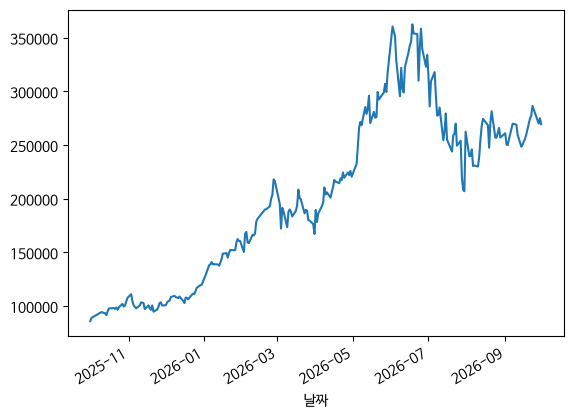

In [9]:
df["종가"].plot()

### ⑥ 빠진 날이나 이상한 값이 있나

힌트: `df.isna().sum()`, `df.describe()` · 거래량이 0인 날은?

In [10]:
df.isna().sum()
# 모두 0으로 빠진 데이터 없음

시가     0
고가     0
저가     0
종가     0
거래량    0
등락률    0
dtype: int64

In [11]:
df.describe()

,시가,고가,저가,종가,거래량,등락률
count,241.00000,241.000000,241.000000,241.000000,2.410000e+02,241.000000
mean,203807.46888,208733.402490,198579.668050,203632.365145,2.740873e+07,0.599978
std,77539.55030,80209.269093,74241.642217,77199.295321,1.068526e+07,4.830110
min,84900.00000,86200.000000,84700.000000,86000.000000,1.090553e+07,-13.385827
25%,134600.00000,138600.000000,132700.000000,137600.000000,1.988448e+07,-1.892042
50%,202500.00000,207500.000000,199600.000000,203500.000000,2.485917e+07,0.804829
75%,267000.00000,272000.000000,260000.000000,268500.000000,3.353017e+07,3.218391
max,372500.00000,374500.000000,352000.000000,362500.000000,8.942795e+07,26.811594


## ➕ 더 궁금한 것 (대화 중에 나온 질문)

### ⑦ 가장 크게 오른 날 / 내린 날은 언제?

`describe()`에서 등락률 max **+26.8%**, min **-13.4%** — 삼성전자치고 너무 큼.

힌트: `df["등락률"].idxmax()`, `df["등락률"].idxmin()` → 그날 뉴스 검색해보기

- 진짜 뉴스가 있다 → "뉴스는 차트에 결과로만 남는다"
- 아무 일도 없다 → 데이터 오류 의심 (전처리 점검)

In [12]:
df["등락률"].max(), df["등락률"].idxmax()

(np.float64(26.811594202898554), Timestamp('2026-07-31 00:00:00'))

In [13]:
df["등락률"].min(), df["등락률"].idxmin()

(np.float64(-13.385826771653544), Timestamp('2026-07-28 00:00:00'))

#### 🔍 그날 무슨 일이? (Claude가 뉴스 검색, 2026-10-04)

**그 주 흐름** (pykrx로 확인)

| 날짜 | 종가 | 등락률 | 거래량 |
|---|---|---|---|
| 7/24 (금) | 249,500 | −7.6% | 2,618만 |
| 7/27 (월) | 254,000 | +1.8% | 2,330만 |
| **7/28 (화)** | **220,000** | **−13.4%** ← 최대 하락 | **4,164만** |
| 7/29 (수) | 208,500 | −5.2% | **6,556만** |
| 7/30 (목) | 207,000 | −0.7% | 4,669만 |
| **7/31 (금)** | **262,500** | **+26.8%** ← 최대 상승 | **5,848만** |
| 8/3 (월) | 239,500 | −8.8% | 2,783만 |

→ 두 날은 **사흘 간격**. 거래량이 평소(평균 약 2,700만)의 1.5~2.5배로 터짐.

**7/28 −13.4% — 시장 전체 폭락**
- 코스피 −8%, **서킷브레이커** 발동 (시장 급락 시 거래를 잠시 멈추는 장치)
- 원인으로 꼽힌 것: 중국 D램 업체 **CXMT 상장**(경쟁 우려) · **AI 투자 붐 지속 여부** 의심 → 반도체주 차익실현 · 중국 노광장비 개발 소식
- 삼성전자 자체 문제라기보다 **반도체 업종 전체에 대한 공포**

**7/31 +26.8% — 급반등**
- 4거래일 하락을 끊고 반등. SK하이닉스도 같이 급등 ("투톱 급등 랠리")
- 꼽힌 이유: 과매도 상태에서의 반등 · 반도체 업황 기대(HBM 점유율, 2분기 실적) 회복
- ⚠️ 기사마다 다름 — 한 매체는 **"뚜렷한 호재 없이 26%대 폭등"**. 한 가지 뉴스로 단정하기 어려움

**출처**
- [반도체주 급락 원인 (다음)](https://v.daum.net/v/20260728100616889) · [오늘 왜 폭락했나 (Investing.com)](https://kr.investing.com/news/stock-market-news/article-93CH-2031438)
- [투톱 급등 랠리 (CBC뉴스)](https://www.cbci.co.kr/news/articleView.html?idxno=593584) · [뚜렷한 호재 없이 26%대 폭등 (재경일보)](https://news.jkn.co.kr/post/951581) · [오늘 급등한 이유 (Investing.com)](https://kr.investing.com/news/stock-market-news/article-93CH-2036000)

**연습 관점에서**
1. 데이터 오류가 아니라 **진짜 이벤트** → 이상치라고 함부로 지우면 안 됨
2. 7/28은 **과거 차트에 없는 정보**(중국 업체 상장, 시장 공포) → 차트만으로는 예측 어려움
3. 7/31은 "많이 떨어진 뒤 반등"이라는 **차트 패턴**으로 설명될 여지 있음
4. 시장 전체가 같이 움직이는 날이 있음 → 코스피 지수를 입력으로 같이 넣을 근거


### ⑧ `freq` 옵션 — 일봉 말고 월봉·연봉으로 받으면?

`help`에 나온 `freq`: `"d"` 일 / `"m"` 월 / `"y"` 년

힌트: `stock.get_market_ohlcv("20251001", "20260930", "005930", freq="m")` → `shape`가 몇 줄로 바뀌나?

In [14]:
stock.get_market_ohlcv("20251001","20260930","005930",freq="m")

,시가,고가,저가,종가,거래량
날짜,,,,,
2025-10-31,84900,108600,84700,107500,484630984
2025-11-30,106900,112400,94500,100500,472946077
2025-12-31,102000,121200,99900,119900,389028028
2026-01-31,120200,166600,120200,160500,649829602
2026-02-28,155700,223000,150400,216500,538540611
2026-03-31,209500,212500,167000,167200,689928910
2026-04-30,179000,230000,175000,220500,534763797
2026-05-31,228000,323000,224000,317000,622815748
2026-06-30,319500,374500,287500,334000,704005604


### ⑨ 일봉으로 월봉을 직접 만들 수 있나? (리샘플링)

컬럼마다 합치는 방법이 다름: 시가=첫날, 고가=최대, 저가=최소, 종가=마지막날, 거래량=합계

힌트: `df.resample("ME").agg({"시가": "first", "고가": "max", "저가": "min", "종가": "last", "거래량": "sum"})`

→ ⑧에서 받은 월봉이랑 **같은지** 비교해보기

In [15]:
df.resample("ME").agg({"시가": "first", "고가": "max", "저가": "min", "종가": "last", "거래량": "sum"})

,시가,고가,저가,종가,거래량
날짜,,,,,
2025-10-31,84900,108600,84700,107500,484630984
2025-11-30,106900,112400,94500,100500,472946077
2025-12-31,102000,121200,99900,119900,389028028
2026-01-31,120200,166600,120200,160500,649829602
2026-02-28,155700,223000,150400,216500,538540611
2026-03-31,209500,212500,167000,167200,689928910
2026-04-30,179000,230000,175000,220500,534763797
2026-05-31,228000,323000,224000,317000,622815748
2026-06-30,319500,374500,287500,334000,704005604


### ⑩ 수정주가(`adjusted`)를 켜고 끄면 뭐가 달라지나?

삼성전자는 **2018년 5월 50:1 액면분할** → 2018년 구간으로 비교하면 차이가 보일 것

힌트: `stock.get_market_ohlcv("20180401", "20180630", "005930", adjusted=False)` 와 `adjusted=True` 를 각각 받아서 종가 그래프 비교

In [16]:
stock.get_market_ohlcv("20180401", "20180630", "005930", adjusted=False)

,시가,고가,저가,종가,거래량,거래대금,등락률
날짜,,,,,,,
2018-04-02,2450000,2461000,2425000,2427000,142313,346383448000,-1.38
2018-04-03,2394000,2407000,2364000,2406000,255365,609108588000,-0.87
2018-04-04,2408000,2413000,2346000,2346000,247684,586682025000,-2.49
2018-04-05,2370000,2469000,2367000,2437000,264912,642625208000,3.88
2018-04-06,2400000,2429000,2370000,2420000,250654,603210892000,-0.70
2018-04-09,2413000,2472000,2410000,2460000,199008,488395543080,1.65
2018-04-10,2427000,2461000,2402000,2444000,219687,534757298912,-0.65
2018-04-11,2495000,2495000,2430000,2443000,201022,495246434000,-0.04
2018-04-12,2472000,2472000,2444000,2450000,249325,612210717000,0.29


In [ ]:
stock.get_market_ohlcv("20180401", "20180630", "005930", adjusted=True) ## 기본은 True

,시가,고가,저가,종가,거래량,등락률
날짜,,,,,,
2018-04-02,49000,49220,48500,48540,142313,-1.381552
2018-04-03,47880,48140,47280,48120,255365,-0.865266
2018-04-04,48160,48260,46920,46920,247684,-2.493766
2018-04-05,47400,49380,47340,48740,264912,3.878943
2018-04-06,48000,48580,47400,48400,250654,-0.697579
2018-04-09,48260,49440,48200,49200,199008,1.652893
2018-04-10,48540,49220,48040,48880,219687,-0.650407
2018-04-11,49900,49900,48600,48860,201022,-0.040917
2018-04-12,49440,49440,48880,49000,249325,0.286533


---

✍️ 알게 된 것:

- 